# Genome-scale metabolic models

## Preparation

In [56]:
from cobra.io import read_sbml_model

In [57]:
model = read_sbml_model('data/iJO1366.xml.gz')

## What is in a genome-scale metabolic model? (10 + 5)

In [58]:
model

Name,iJO1366
Memory address,2c367410ca0
Number of metabolites,1805
Number of reactions,2583
Number of genes,1367
Number of groups,36
Objective expression,1.0*BIOMASS_Ec_iJO1366_core_53p95M - 1.0*BIOMASS_Ec_iJO1366_core_53p95M_reverse_5c8b1
Compartments,"cytosol, extracellular space, periplasm"


### Metabolites

The model contains a list of metabolites. Here are the first ten.

In [59]:
model.metabolites[0:10]

[<Metabolite 10fthf_c at 0x2c367411330>,
 <Metabolite 12dgr120_c at 0x2c3674117b0>,
 <Metabolite 12dgr140_c at 0x2c367411390>,
 <Metabolite 12dgr141_c at 0x2c367411090>,
 <Metabolite 12dgr160_c at 0x2c3674113c0>,
 <Metabolite 12dgr161_c at 0x2c367411900>,
 <Metabolite 12dgr180_c at 0x2c367411480>,
 <Metabolite 12dgr181_c at 0x2c367411150>,
 <Metabolite 12ppd__R_c at 0x2c367411540>,
 <Metabolite 12ppd__S_c at 0x2c3674114e0>]

There are 1805 metabolites in the model.

In [60]:
len(model.metabolites)

1805

One can access a specific metabolite using dot notation.

In [61]:
model.metabolites.g3p_c

Metabolite identifier,g3p_c
Name,Glyceraldehyde 3-phosphate
Memory address,0x2c367336470
Formula,C3H5O6P
Compartment,c
In 14 reaction(s),"DXPS, TALA, DDPGALA, TRPS1, FBA, F6PA, TPI, GAPD, TRPS3, TKT1, DRPA, EDA, TKT2, TGBPA"


<div class="alert alert-warning">

**Warning:** One cannot use dot notation to access metabolites, reactions, or genes if their identifiers do not resemble proper Python variable names.

</div>

In [62]:
# the line below results in an error, uncomment to try
# model.metabolites.10fthf_c


#  File "<ipython-input-5-2772b042e9ed>", line 1
#     model.metabolites.10fthf_c
#                        ^
# SyntaxError: invalid syntax

<div class="alert alert-success">

**Solution:** Use the method `get_by_id` instead!

</div>

In [63]:
model.metabolites.get_by_id('10fthf_c')

Metabolite identifier,10fthf_c
Name,10-Formyltetrahydrofolate
Memory address,0x2c367411330
Formula,C20H21N7O7
Compartment,c
In 9 reaction(s),"FTHFD, BIOMASS_Ec_iJO1366_WT_53p95M, MTHFC, FMETTRS, BIOMASS_Ec_iJO1366_core_53p95M, ULA4NFT, FTHFLi, AICART, GARFT"


Metabolites are associated with compartments in the cell. Glyceraldehyde 3-phosphate (`g3p_c`) is associated with the `c` (Cytosol) compartment.

In [64]:
model.metabolites.g3p_c.compartment

'c'

The _E. coli_ model has three compartments.

In [65]:
model.compartments

{'c': 'cytosol', 'e': 'extracellular space', 'p': 'periplasm'}

Some metabolites (like Glucose for example) can be associated with multiple compartments.

In [66]:
model.metabolites.glc__D_c.compartment

'c'

In [67]:
model.metabolites.glc__D_p.compartment

'p'

The full name of the metabolite is available via the `.name` attribute. 

In [68]:
model.metabolites.glc__D_c.name

'D-Glucose'

One can look up the molecular formula of glucose.

In [69]:
model.metabolites.g3p_c.formula

'C3H5O6P'

The `.elements` attribute returns a dictionary representation of the formula.

In [70]:
model.metabolites.g3p_c.elements

{'C': 3, 'H': 5, 'O': 6, 'P': 1}

Furthermore, one can look up the molecular weight of a metabolite.

In [71]:
model.metabolites.g3p_c.formula_weight

168.041961

One can gather additional information (like references to external datbases) about the metabolite through the annotation attribute.

In [72]:
model.metabolites.g3p_c.annotation

{'sbo': 'SBO:0000247',
 'bigg.metabolite': 'g3p',
 'seed.compound': 'cpd00102',
 'metanetx.chemical': 'MNXM2378',
 'kegg.compound': ['C00118', 'C00661'],
 'hmdb': 'HMDB01112',
 'chebi': ['CHEBI:12983',
  'CHEBI:12984',
  'CHEBI:14333',
  'CHEBI:17138',
  'CHEBI:181',
  'CHEBI:18324',
  'CHEBI:21026',
  'CHEBI:29052',
  'CHEBI:5446',
  'CHEBI:58027',
  'CHEBI:59776'],
 'unipathway.compound': ['UPC00118', 'UPC00661'],
 'biocyc': 'META:GAP',
 'reactome': '29578'}

One can use these annotations to look up the compound on [KEGG](http://www.genome.jp/dbget-bin/www_bget?cpd:C00118) for example.

Metabolites are not isolated things. They participate in reactions as substrates and products.

In [73]:
model.metabolites.g3p_c.reactions

frozenset({<Reaction DDPGALA at 0x2c36bab9c60>,
           <Reaction DRPA at 0x2c36bb2e980>,
           <Reaction DXPS at 0x2c36bb51c30>,
           <Reaction EDA at 0x2c36bb8f3a0>,
           <Reaction F6PA at 0x2c36bbbdba0>,
           <Reaction FBA at 0x2c36bbf6ad0>,
           <Reaction GAPD at 0x2c36bd45540>,
           <Reaction TALA at 0x2c368165840>,
           <Reaction TGBPA at 0x2c367f949d0>,
           <Reaction TKT1 at 0x2c367fd09d0>,
           <Reaction TKT2 at 0x2c367fd11b0>,
           <Reaction TPI at 0x2c367fd3910>,
           <Reaction TRPS1 at 0x2c367fa4ac0>,
           <Reaction TRPS3 at 0x2c367fa5540>})

### Reactions

The model contains a list of reactions. Here are the first 10 of them.

In [74]:
model.reactions[0:10]

[<Reaction DM_4crsol_c at 0x2c36b5240a0>,
 <Reaction DM_5drib_c at 0x2c36b526fe0>,
 <Reaction DM_aacald_c at 0x2c36b527280>,
 <Reaction DM_amob_c at 0x2c36b527430>,
 <Reaction DM_mththf_c at 0x2c36b5274f0>,
 <Reaction DM_oxam_c at 0x2c36b5275b0>,
 <Reaction BIOMASS_Ec_iJO1366_WT_53p95M at 0x2c36b527670>,
 <Reaction BIOMASS_Ec_iJO1366_core_53p95M at 0x2c36b527730>,
 <Reaction EX_12ppd__R_e at 0x2c36b527fd0>,
 <Reaction EX_12ppd__S_e at 0x2c36b5272b0>]

There are 2583 reactions in the model.

In [75]:
len(model.reactions)

2583

Let's take a closer look at the reactions associated with Glyceraldehyde 3-phosphate (`g3p`).

In [76]:
for reaction in model.metabolites.g3p_c.reactions:
    print(reaction, reaction.name)

DXPS: g3p_c + h_c + pyr_c --> co2_c + dxyl5p_c 1-deoxy-D-xylulose 5-phosphate synthase
TALA: g3p_c + s7p_c <=> e4p_c + f6p_c Transaldolase
DDPGALA: 2dh3dgal6p_c <=> g3p_c + pyr_c 2-dehydro-3-deoxy-6-phosphogalactonate aldolase
TRPS1: 3ig3p_c + ser__L_c --> g3p_c + h2o_c + trp__L_c Tryptophan synthase (indoleglycerol phosphate)
FBA: fdp_c <=> dhap_c + g3p_c Fructose-bisphosphate aldolase
F6PA: f6p_c <=> dha_c + g3p_c Fructose 6-phosphate aldolase
TPI: dhap_c <=> g3p_c Triose-phosphate isomerase
GAPD: g3p_c + nad_c + pi_c <=> 13dpg_c + h_c + nadh_c Glyceraldehyde-3-phosphate dehydrogenase
TRPS3: 3ig3p_c --> g3p_c + indole_c Tryptophan synthase (indoleglycerol phosphate)
TKT1: r5p_c + xu5p__D_c <=> g3p_c + s7p_c Transketolase
DRPA: 2dr5p_c --> acald_c + g3p_c Deoxyribose-phosphate aldolase
EDA: 2ddg6p_c --> g3p_c + pyr_c 2-dehydro-3-deoxy-phosphogluconate aldolase
TKT2: e4p_c + xu5p__D_c <=> f6p_c + g3p_c Transketolase
TGBPA: tagdp__D_c <=> dhap_c + g3p_c Tagatose-bisphosphate aldolase


The second reaction in this list is Glyceraldehyde-3-phosphate dehydrogenase (GAPD).

In [77]:
model.reactions.GAPD.name

'Glyceraldehyde-3-phosphate dehydrogenase'

A reaction has a flux expression, which in cobrapy is coded as the forward flux + the reverse flux (a convenient way to represent the mathematical problem).

In [78]:
model.reactions.GAPD.flux_expression

1.0*GAPD - 1.0*GAPD_reverse_459c1

### Genes and gene-protein-reaction associations

The model also contains genes (perhaps more appropriately gene products) and they belong to reactions.

In [79]:
model.genes[0:5]

[<Gene b2215 at 0x2c36b376e00>,
 <Gene b1377 at 0x2c36b376da0>,
 <Gene b0241 at 0x2c36b376f80>,
 <Gene b0929 at 0x2c36b376e30>,
 <Gene b4035 at 0x2c36b376ef0>]

In [80]:
model.genes.b1779.reactions

frozenset({<Reaction E4PD at 0x2c36bb520b0>, <Reaction GAPD at 0x2c36bd45540>})

The gapA (b1779) gene is the only one associated to reaction glyceraldehyde-3-phosphate dehydrogenase.

In [81]:
model.reactions.GAPD.gene_reaction_rule

'b1779'

Phosphofructokinase (PFK) on the other hand seems to be associated with to isozymes.

In [82]:
model.reactions.PFK.gene_reaction_rule

'b3916 or b1723'

One can display the gene names (typical 4 letter gene codes) instead of the identifiers (Blattner numbers in this case).

In [83]:
model.reactions.PFK.gene_name_reaction_rule

'pfkA or pfkB'

Reactions are functional if all genes are functional

In [84]:
model.reactions.PFK

Reaction identifier,PFK
Name,Phosphofructokinase
Memory address,0x2c366f52530
Stoichiometry,"atp_c + f6p_c --> adp_c + fdp_c + h_c ATP + D-Fructose 6-phosphate --> ADP + D-Fructose 1,6-bisphosphate + H+"
GPR,b3916 or b1723
Lower bound,0.0
Upper bound,1000.0


In [85]:
print(model.genes.b3916.functional, model.genes.b1723.functional, model.reactions.PFK.functional)

True True True


If we knock out one of the isozymes, the PFK reaction stays functional, but not if we knock both.

In [86]:
model_copy = model.copy()
model_copy.genes.b3916.knock_out()
print(model_copy.reactions.PFK.functional)

model_copy = model.copy()
model_copy.genes.b3916.knock_out()
model_copy.genes.b1723.knock_out()
print(model_copy.reactions.PFK.functional)

True
False


### Objective

In the iJO1366 model, the default objective is to maximize the flux through the biomass reaction (i.e. growth). 

In [87]:
print(model.objective)

Maximize
1.0*BIOMASS_Ec_iJO1366_core_53p95M - 1.0*BIOMASS_Ec_iJO1366_core_53p95M_reverse_5c8b1


### Querying

One can use `.query('search term', 'attribute_to_search_in')` to search in model metabolites, reactions, and genes. For example, one can search metabolites that contain the term _glucose_ in their name.

In [88]:
for metabolite in model.metabolites.query('glucose', 'name'):
    print(metabolite.name)

6-Acetyl-D-glucose
ADPglucose
DTDP-4-dehydro-6-deoxy-D-glucose
DTDPglucose
UDPglucose
UDPglucose
UDPglucose


### Exercises

Convert the cells below to code and fill in the blanks

In [89]:
# which reactions includes cytosolic atp?
model.metabolites.atp_c

Metabolite identifier,atp_c
Name,ATP
Memory address,0x2c367334e20
Formula,C10H12N5O13P3
Compartment,c
In 359 reaction(s),"CCGS, SULabcpp, PE140abcpp, PE161abcpp, GLYCK, PGP141abcpp, ADK1, PPS, XYLK2, PG140abcpp, PGP180abcpp, ACOLIPAabctex, COLIPAabcpp, HISTRS, BUTSO3abcpp, ASPTRS, GLYC3Pabcpp, DURIK1, CRNDabcpp,..."


In [90]:
# which metabolite is named adenosine
model.metabolites.query("adenosine", "name")

[<Metabolite 5mta_c at 0x2c3674137c0>,
 <Metabolite dad_2_c at 0x2c367335d20>,
 <Metabolite dad_5_c at 0x2c367335d50>,
 <Metabolite dad_2_e at 0x2c36b135ae0>,
 <Metabolite dad_2_p at 0x2c36b20c1f0>]

In [91]:
# which genes are necessary for PFK reaction?
model.reactions.PFK.genes

frozenset({<Gene b1723 at 0x2c36b4a7910>, <Gene b3916 at 0x2c36b4a7940>})

## Simulating models with regular flux balance analysis (FBA) (5 + 5)

In [92]:
model.optimize()

,fluxes,reduced_costs
DM_4crsol_c,0.000219,0.000000
DM_5drib_c,0.000221,0.000000
DM_aacald_c,0.000000,0.000000
DM_amob_c,0.000002,0.000000
DM_mththf_c,0.000440,0.000000
...,...,...
ZN2abcpp,0.000000,-0.008295
ZN2t3pp,0.000000,-0.002074
ZN2tpp,0.000335,0.000000
ZNabcpp,0.000000,-0.008295


Sometimes a solution cannot be found. For example, setting the lower bound of the objective function to a very high value that the model cannot achieve will trigger a warning when trying to optimize the model. Parameters reported from an infeasible model are not meaningful to interpret (except in rare occasions when you may want to figure out why a model is infeasible).

In [93]:
infeasible_model = model.copy()
infeasible_model.reactions.BIOMASS_Ec_iJO1366_core_53p95M.lower_bound = 100000
infeasible_model.optimize()

ValueError: The lower bound must be less than or equal to the upper bound (100000 <= 1000.0).

Mathematical solvers are now so fast that for computing the solution can be even faster than it takes to collect the values from the solver. If we are only interested in the flux value of a single reaction or the objective, it is faster to use `model.slim_optimize` which only does the optimization and returnsm the objective value leaving it up to you to fetch other values that you may need. For example, let's optimize and get the flux value of the `ATPM` reaction.

In [ ]:
%%time
solution = model.optimize()
solution.fluxes['ATPM']

CPU times: total: 62.5 ms
Wall time: 70.9 ms


np.float64(3.15)

In [ ]:
%%time
model.slim_optimize()
model.reactions.ATPM.flux

CPU times: total: 15.6 ms
Wall time: 14.6 ms


3.15

### Exercises

Convert the cell below to code and fill in the blanks.

Optimize for acetate production at minimum 0.1 $h^{-1}$ growth rate

In [95]:
model.reactions.BIOMASS_Ec_iJO1366_core_53p95M.lower_bound = 0.1
model.objective = model.reactions.EX_ac_e
model.optimize()

,fluxes,reduced_costs
DM_4crsol_c,2.230000e-05,0.000000
DM_5drib_c,2.250000e-05,0.000000
DM_aacald_c,0.000000e+00,-0.673367
DM_amob_c,2.000000e-07,0.000000
DM_mththf_c,4.480000e-05,0.000000
...,...,...
ZN2abcpp,0.000000e+00,-0.160804
ZN2t3pp,0.000000e+00,-0.040201
ZN2tpp,3.410000e-05,0.000000
ZNabcpp,0.000000e+00,-0.160804


## The math (5)

### The mathematical problem

We can calculate fluxes using our model by formulating it as a mathematical problem. There, fluxes through reactions become variables and metabolites become constraints. By deciding that fluxes in and out of the system must add up to zero, we can then compute possible flux values for all reactions (if the model is feasible). We can inspect the whole equation by:

In [96]:
print(str(model.solver)[0:1550])

\* Problem: Unknown *\

Maximize
 obj: + EX_ac_e - EX_ac_e_reverse_0be96

Subject To
 r_1: + ULA4NFT_reverse_07217 - ULA4NFT - MTHFC_reverse_f6fcc + MTHFC
 + GARFT_reverse_7ecb6 - GARFT - FTHFLi_reverse_a6dc7 + FTHFLi
 + FTHFD_reverse_44321 - FTHFD + FMETTRS_reverse_3b6c6 - FMETTRS
 + AICART_reverse_b7b59 - AICART
 + 0.000223 BIOMASS_Ec_iJO1366_core_53p95M_reverse_5c8b1
 - 0.000223 BIOMASS_Ec_iJO1366_core_53p95M
 + 0.000223 BIOMASS_Ec_iJO1366_WT_53p95M_reverse_06c4a
 - 0.000223 BIOMASS_Ec_iJO1366_WT_53p95M = 0
 r_2: - PAPA120_reverse_75d70 + PAPA120 + DAGK120_reverse_7cd00
 - DAGK120 - s_666 + x_665 = 0
 r_3: - PAPA140_reverse_255f5 + PAPA140 + DAGK140_reverse_87f8f
 - DAGK140 - s_668 + x_667 = 0
 r_4: - PAPA141_reverse_945ab + PAPA141 + DAGK141_reverse_f6e5f
 - DAGK141 - s_670 + x_669 = 0
 r_5: - PAPA160_reverse_c64df + PAPA160 + DAGK160_reverse_0238d
 - DAGK160 - s_672 + x_671 = 0
 r_6: - PAPA161_reverse_1bc33 + PAPA161 + DAGK161_reverse_9bfe7
 - DAGK161 - s_674 + x_673 = 0
 r_7: - P

Mostly, we luckily do not have to care much about this as cobrapy will use optlang and dedicated mathematical solvers to do the hard work for us, but it can be good know about the separation between the metabolic model and the mathematical problem.

In [97]:
len(model.variables)

5166

In [98]:
len(model.constraints)

1805

### The stoichiometric matrix S

In [99]:
from cobra.util import create_stoichiometric_matrix

In [100]:
stoich_matrix = create_stoichiometric_matrix(model)
stoich_matrix

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., -1., -1.,  1.]], shape=(1805, 2583))

This is how the the stoichiometry matrix S looks like when visualized as a matrix plot.

In [101]:
%matplotlib inline

In [102]:
import matplotlib.pyplot as plt

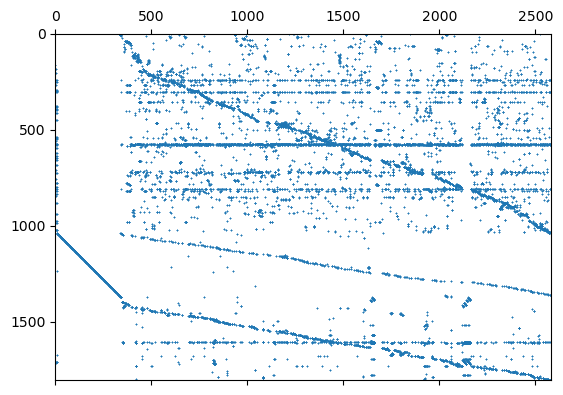

In [105]:
plt.spy(stoich_matrix, precision=0.01, markersize=.2)
plt.show()

<div class="alert alert-info">

**Question:** What are the diagonal and horizontal lines?
</div>
